<a href="https://colab.research.google.com/github/maschu09/mless/blob/main/remote_sensing/Random_forest_classifier_on_remote_sensing_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random forest classifier for landcover classification from remote sensing images

In this tasks, we will use a portion of the [SAT-6](https://csc.lsu.edu/~saikat/deepsat/) dataset from Louisiana State University and NASA Ames Research Center.

For this demonstration, we only use the test dataset, which consists of 81000 samples randomly distributed across 6 landcover classes.

In [1]:
# Random forest classifier for landcover classification
# Author: Ankit Patnala, JSC, 2025; updated by Martin Schultz, April 2026
# Download necessary packages if right kernel is not present
# Not needed in colab
#!pip install pandas
#!pip install scikit-learn
#!pip install matplotlib

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Obtaining the data
The data is available via this B2share link [link](https://b2share.eudat.eu/records/89654eac10724d30a6c7e51f2c5422de). Download all the files at the same folder path where you are creating this notebook

Alternatively use the following wget commands to download the data

The following cell can be executed in Google colab

In [3]:
# !mkdir -p data
# !wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/X_test_sat6.csv
# !wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/y_test_sat6.csv
# !wget -P data https://b2share.eudat.eu/api/files/a697daf7-7570-44ff-854c-0fab43f2b52c/sat6annotations.csv


In [4]:
# load the csv file with the image data. Each row belongs to one sample. Each sample has 3136 columns i.e. 4 channels (R,G,B, and NIR) and 28 \times 28 spatial size
landcover_df = pd.read_csv("./data/X_test_sat6.csv",header=None)
landcover_df

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
0,95,91,61,157,105,113,101,179,50,35,...,107,181,118,137,127,205,90,105,86,183
1,102,102,103,137,108,110,116,154,88,83,...,91,157,95,92,84,143,89,85,76,130
2,47,54,95,10,79,89,108,15,96,131,...,118,17,82,98,125,18,61,69,113,13
3,200,181,178,218,192,177,176,214,162,141,...,139,203,157,138,125,193,147,128,107,187
4,85,101,100,15,87,102,97,16,54,71,...,74,8,37,49,76,6,27,43,69,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80995,82,82,115,17,104,123,131,23,100,119,...,146,32,137,152,159,44,159,166,166,61
80996,170,148,147,174,203,188,163,190,211,197,...,134,172,163,154,136,175,172,157,143,177
80997,140,136,126,190,156,163,152,208,152,170,...,126,162,93,111,119,170,68,66,61,123
80998,89,87,99,13,64,66,89,9,16,26,...,111,15,49,52,97,11,47,56,102,9


&#x1F479;  _Task:_ Make sure you understand this data structure.

&#x1F479;  _Question:_ What would you need to do to extract only the green and the infrared channel from this data?

**Answer:** Each row is a flattened 28 x 28 image with four channels in the order R, G, B, NIR. I first reshape a row (or a set of rows) to (-1, 28, 28, 4), then keep channels [1, 3] for green and NIR, and finally flatten again if the classifier expects a 2D feature matrix.


In [5]:
# Read the annotation file to get the annotation i.e. classname corresponding to the labels
annotations = pd.read_csv("./data/sat6annotations.csv", header=None)
print(annotations)
labels = annotations[0].values
print(f'class labels: {labels}')

             0  1  2  3  4  5  6
0     building  1  0  0  0  0  0
1  barren_land  0  1  0  0  0  0
2        trees  0  0  1  0  0  0
3    grassland  0  0  0  1  0  0
4         road  0  0  0  0  1  0
5        water  0  0  0  0  0  1
class labels: <StringArray>
['building', 'barren_land', 'trees', 'grassland', 'road', 'water']
Length: 6, dtype: str


The data structure that you see above is called _one-hot encoding_

&#x1F479; _Question:_ What is the advantage of this encoding compared to a simple class label like '0', '1', '2', '3', '4', '5', or text labels like 'building', 'barren_land', ...?

**Answer:** One-hot labels make the class membership explicit in separate columns, so every row has one clear target class and the class order is unambiguous. This format is also convenient for many machine-learning libraries and neural-network losses. For the random forest I still convert the one-hot rows back to a single class index when calculating per-class metrics.


In [6]:
# load the csv file with the labels of all samples
labels_df = pd.read_csv("./data/y_test_sat6.csv",header=None)
print(labels_df)
# get the names of the class labels (here, only "0" to "5")
# These correspond to the labels printed above
column_names = labels_df.columns.values

       0  1  2  3  4  5
0      0  0  1  0  0  0
1      0  0  1  0  0  0
2      0  0  0  0  0  1
3      0  1  0  0  0  0
4      0  0  0  0  0  1
...   .. .. .. .. .. ..
80995  0  0  0  0  0  1
80996  0  1  0  0  0  0
80997  0  0  1  0  0  0
80998  0  0  0  0  0  1
80999  0  0  1  0  0  0

[81000 rows x 6 columns]


# Plot random samples for illustration

&#x1F479; _Task:_ Make sure you understand the following code for creating balanced samples from the overall dataset and the reshaping of ther data that is needed for plotting.

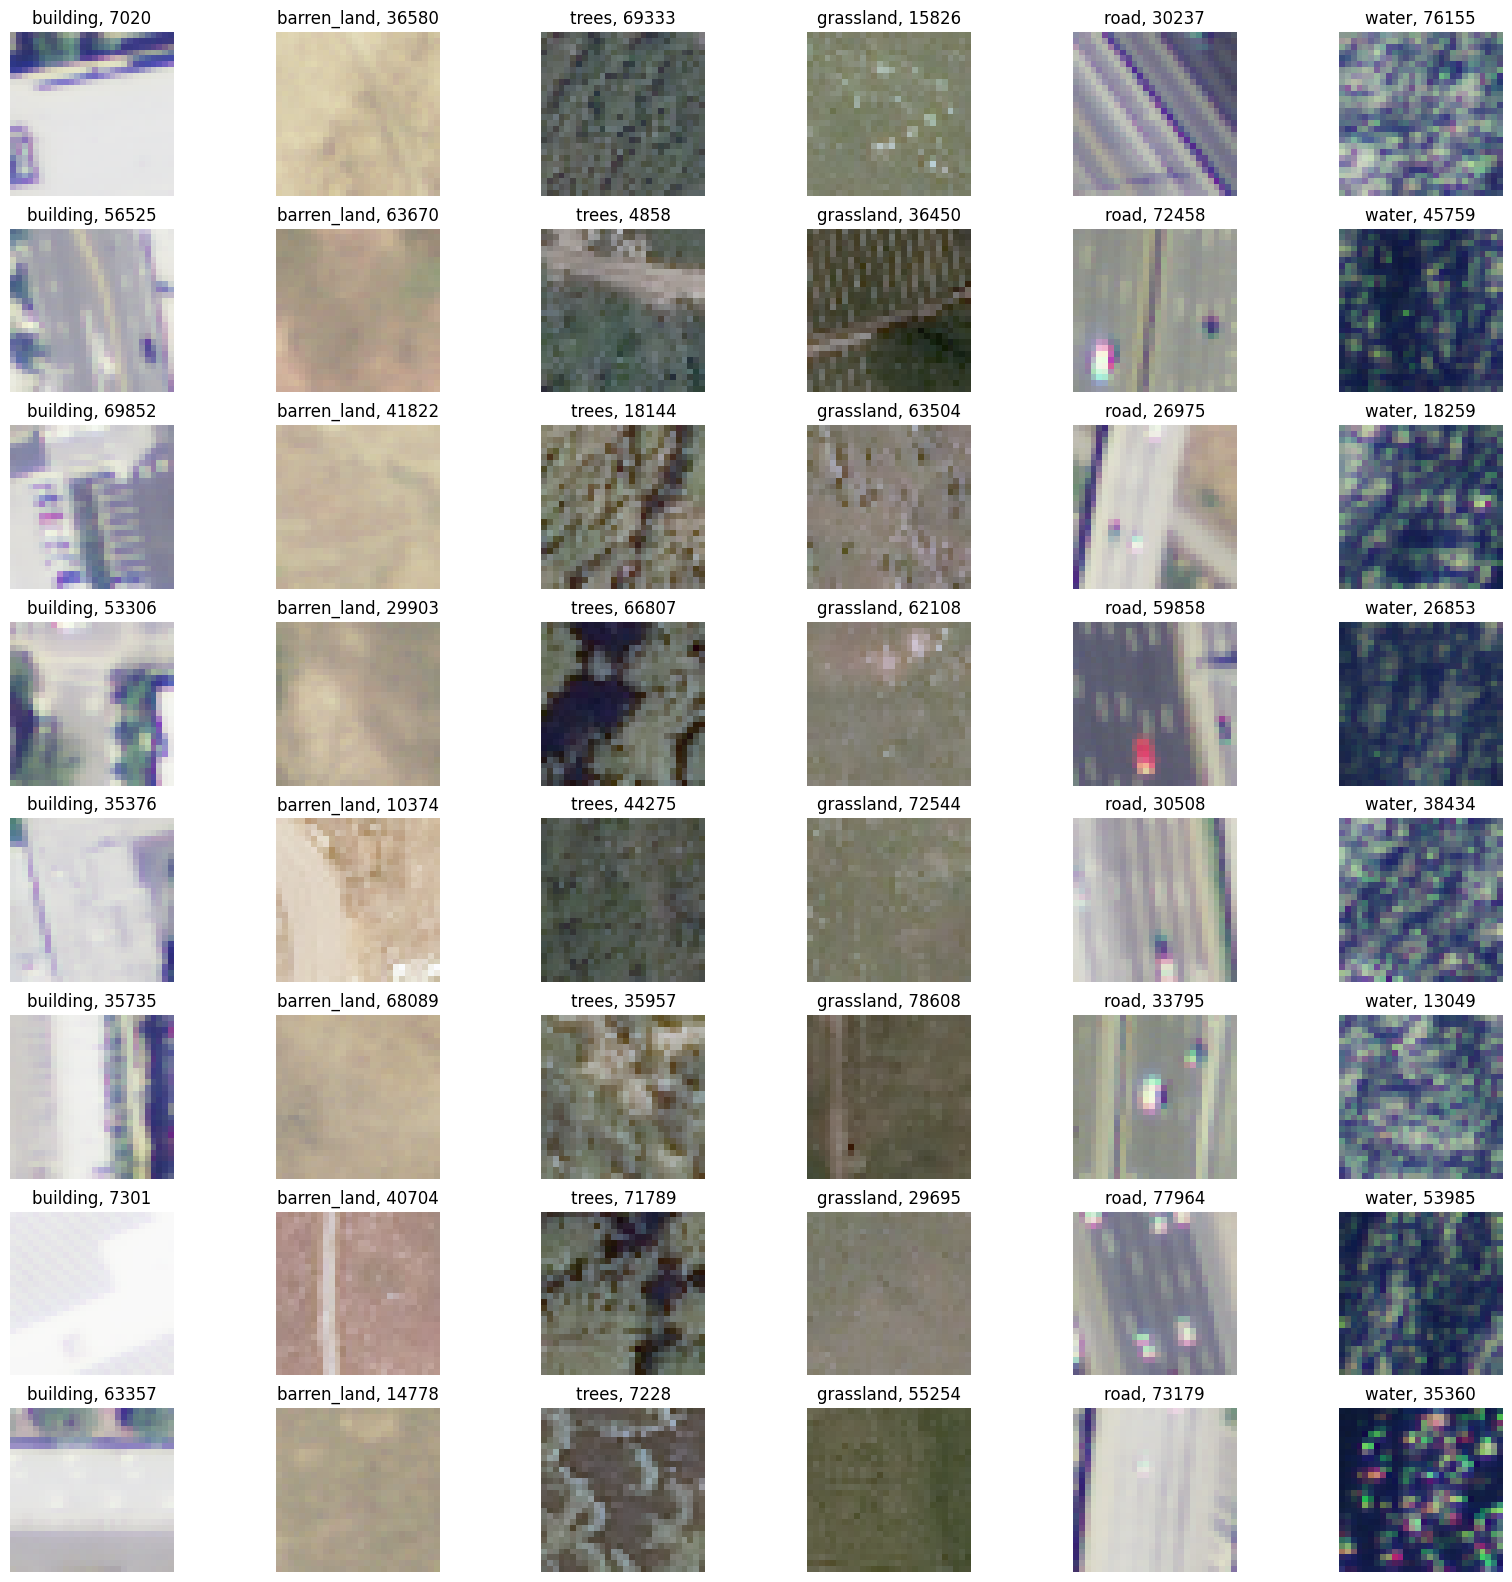

In [7]:
num_classes = len(column_names)
num_samples = 8  # number of rows to plot
sample_idx = []
sample_rng = np.random.default_rng(RANDOM_STATE)

for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_samples from this index list - make sure to avoid duplicates
    sample_idx.append(sample_rng.choice(
        np.where(class_idx.values)[0],
        size=num_samples,
        replace=False
    ).tolist())

fig, ax = plt.subplots(num_samples, num_classes, figsize=(20, 20))
for i in range(num_samples):
    for j in range(num_classes):
        data_index = sample_idx[j][i]
        ax[i, j].set_title(f"{labels[j]}, {data_index}")
        ax[i, j].axis("off")
        data = np.reshape(landcover_df.iloc[data_index].values, (-1, 28, 28, 4))
        ax[i, j].imshow(data[0, ..., :3])

plt.show()


## Inspect the image channels

Each sample has four channels: R, G, B, and NIR. I inspected one patch channel-by-channel and also compared the average channel intensity per class. This is important before removing channels, because the NIR channel is not visible in an RGB plot but can still carry class information.


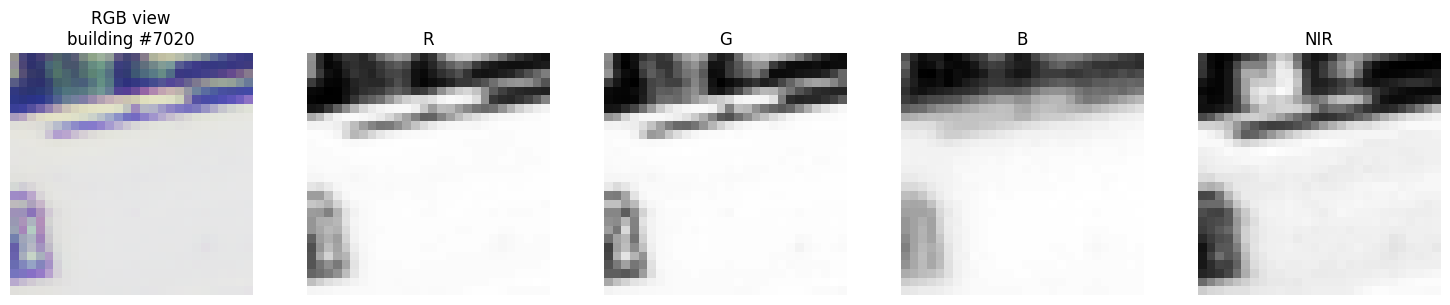

,R,G,B,NIR
building,188.3,187.4,195.8,122.6
barren_land,173.5,158.5,136.7,180.5
trees,91.0,92.8,84.5,145.1
grassland,118.5,117.3,101.6,171.1
road,152.5,153.0,151.8,87.2
water,70.6,85.8,107.3,17.0


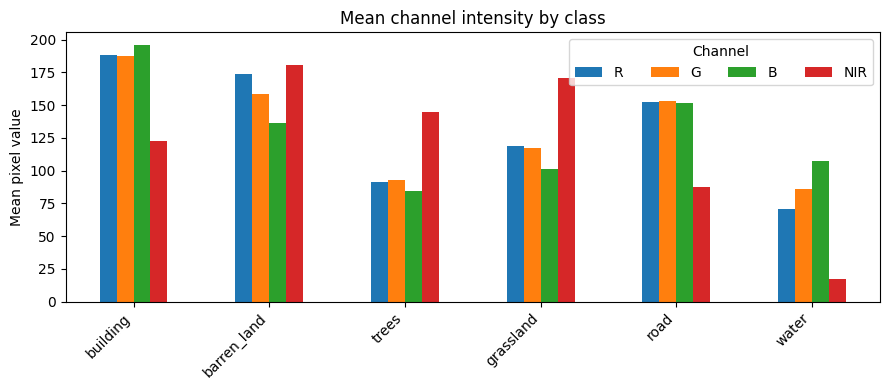

In [8]:
channel_names = ["R", "G", "B", "NIR"]
all_images = landcover_df.values.reshape((-1, 28, 28, 4))
class_ids = labels_df.values.argmax(axis=1)

example_index = sample_idx[0][0]
example_image = landcover_df.iloc[example_index].values.reshape((28, 28, 4))

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(example_image[:, :, :3])
axes[0].set_title(f"RGB view\n{labels[0]} #{example_index}")
axes[0].axis("off")

for channel_id, channel_name in enumerate(channel_names):
    axes[channel_id + 1].imshow(example_image[:, :, channel_id], cmap="gray")
    axes[channel_id + 1].set_title(channel_name)
    axes[channel_id + 1].axis("off")

plt.tight_layout()
plt.show()

class_channel_means = np.vstack([
    all_images[class_ids == class_id].mean(axis=(0, 1, 2))
    for class_id in range(num_classes)
])

channel_mean_df = pd.DataFrame(
    class_channel_means,
    columns=channel_names,
    index=labels
).round(1)

display(channel_mean_df)

ax = channel_mean_df.plot(kind="bar", figsize=(9, 4))
ax.set_ylabel("Mean pixel value")
ax.set_title("Mean channel intensity by class")
ax.legend(title="Channel", ncols=4)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Create the training and test datasets

Collect equal number of samples from each class for training and testing, respectively

In [9]:
num_train = 1000
num_test = 100
train_idx = []
test_idx = []
split_rng = np.random.default_rng(RANDOM_STATE + 1)

for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    valid_indices = np.where(class_idx.values)[0]

    # shuffle once and split, so train and test do not accidentally overlap
    random_indices = split_rng.permutation(valid_indices)
    test_idx.extend(random_indices[:num_test].tolist())
    train_idx.extend(random_indices[num_test:num_test + num_train].tolist())

print(f"number of train indices: {len(train_idx)}, number of test indices: {len(test_idx)}")


number of train indices: 6000, number of test indices: 600


&#x1F479;  _Question:_ Why use extend here and append above?

**Answer:** append would add a complete list as one nested element. Here I want one long list of individual sample indices from all classes, so extend is the right choice.

&#x1F479;  _Question:_ What is wrong with the above code?

**Answer:** The original version sampled train and test indices independently. That means the same image could appear in both sets, which would make the evaluation too optimistic. I changed the code to shuffle the class indices once and then take separate slices for test and train.


In [10]:
# Shuffle train and test indices
train_idx = split_rng.permutation(train_idx)
test_idx = split_rng.permutation(test_idx)

# Extract images and labels corresponding to the selected indices
train_X = landcover_df.iloc[train_idx]
train_y = labels_df.iloc[train_idx]
test_X = landcover_df.iloc[test_idx]
test_y = labels_df.iloc[test_idx]

# For metrics it is easier to work with one class id per sample
train_y_class = train_y.values.argmax(axis=1)
test_y_class = test_y.values.argmax(axis=1)

overlap = set(train_idx).intersection(set(test_idx))
print(f"train/test overlap: {len(overlap)}")


train/test overlap: 0


&#x1F479; _Question:_ Why do you want to shuffle the samples in the train and test datasets?

**Answer:** Shuffling removes the class order from the selected indices. This is useful because many algorithms and later batching steps assume that samples are mixed instead of grouped class by class.


In [11]:
train_X

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
65688,181,168,141,179,180,167,142,181,189,174,...,142,155,184,168,144,158,187,172,147,158
27908,183,177,143,188,180,174,146,189,179,174,...,146,196,187,174,144,196,191,177,144,196
56032,83,102,99,184,91,104,114,191,103,119,...,129,94,135,127,116,82,101,105,115,70
26452,72,78,60,138,83,93,87,155,71,79,...,96,171,84,88,64,154,101,106,96,166
34879,171,172,174,66,170,172,175,66,168,170,...,208,102,211,214,208,115,215,218,208,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46777,110,120,128,27,80,95,124,18,74,81,...,145,28,113,124,152,34,116,131,151,38
41676,127,108,81,174,148,139,121,192,114,105,...,162,189,189,178,162,190,193,180,165,191
33650,167,168,157,108,155,155,152,100,149,148,...,147,71,83,63,129,62,135,145,136,96
77537,162,154,132,179,156,144,133,176,154,147,...,143,192,189,180,149,192,189,175,145,190


## Define and intialize random classifier from scikit-learn

In [12]:
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

## Train the random forest

In [13]:
rf.fit(train_X, train_y_class)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Check the prediction on the test set

In [14]:
baseline_pred = rf.predict(test_X)
baseline_accuracy = accuracy_score(test_y_class, baseline_pred)
baseline_accuracy

0.9416666666666667

&#x1F479;  _Task:_ Add code to plot a couple of successes and failures (i.e., where predicted labels agree/disagree with the given labels in test_y)

Random forest with R, G, B, and NIR overall accuracy: 0.942
  building: 0.910
  barren_land: 0.970
  trees: 0.960
  grassland: 0.870
  road: 0.940
  water: 1.000


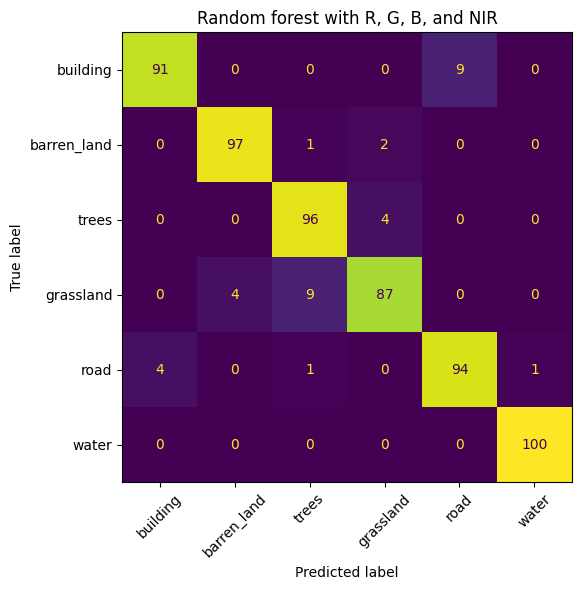

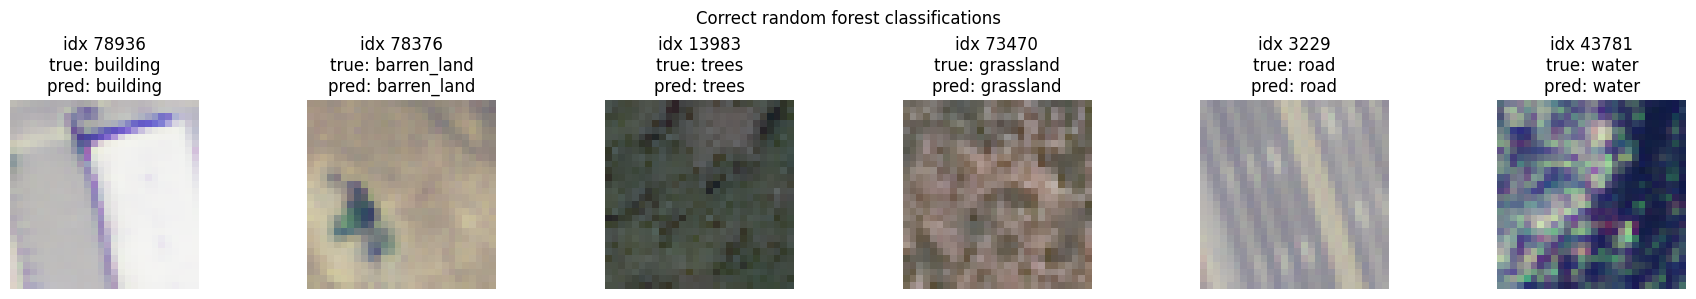

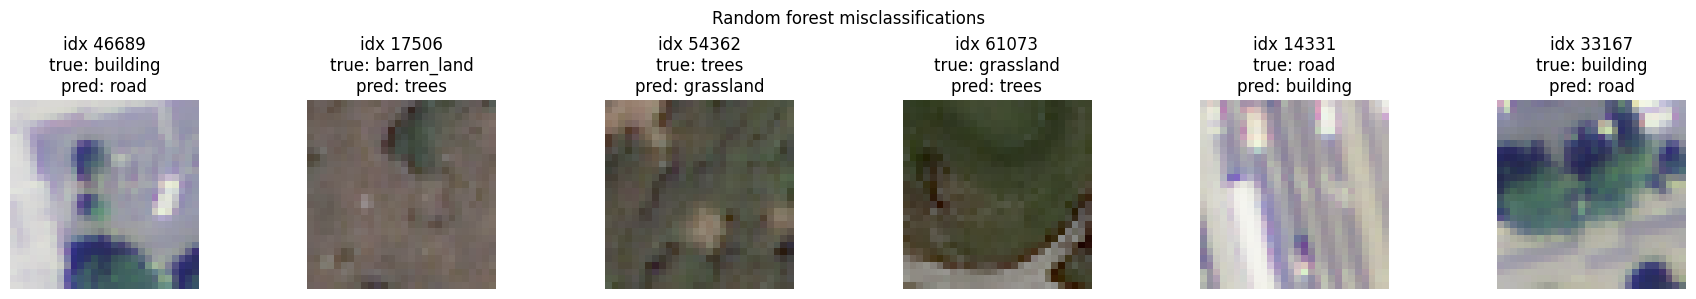

In [15]:
def select_channels(flat_df, channels):
    data = flat_df.values.reshape((-1, 28, 28, 4))
    return data[:, :, :, channels].reshape((data.shape[0], -1))

def evaluate_predictions(true_classes, pred_classes, class_labels, title):
    accuracy = accuracy_score(true_classes, pred_classes)
    cm = confusion_matrix(true_classes, pred_classes, labels=np.arange(len(class_labels)))
    per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

    print(f"{title} overall accuracy: {accuracy:.3f}")
    for label, score in zip(class_labels, per_class_accuracy):
        print(f"  {label}: {score:.3f}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return accuracy, per_class_accuracy, cm

def choose_example_indices(true_classes, pred_classes, correct=True, max_examples=6):
    matches = true_classes == pred_classes if correct else true_classes != pred_classes
    candidates = np.where(matches)[0]
    if len(candidates) == 0:
        return candidates

    # Prefer a mix of true classes instead of taking only the first rows.
    chosen = []
    for class_id in range(len(labels)):
        class_candidates = candidates[true_classes[candidates] == class_id]
        if len(class_candidates) > 0:
            chosen.append(class_candidates[0])
        if len(chosen) == max_examples:
            break

    if len(chosen) < max_examples:
        for candidate in candidates:
            if candidate not in chosen:
                chosen.append(candidate)
            if len(chosen) == max_examples:
                break

    return np.array(chosen)

def plot_classification_examples(flat_df, true_classes, pred_classes, class_labels,
                                 title, correct=True, max_examples=6):
    example_idx = choose_example_indices(true_classes, pred_classes, correct, max_examples)

    if len(example_idx) == 0:
        print(f"No examples found for: {title}")
        return

    fig, axes = plt.subplots(1, len(example_idx), figsize=(3 * len(example_idx), 3))
    if len(example_idx) == 1:
        axes = [axes]

    for ax, local_idx in zip(axes, example_idx):
        original_idx = test_idx[local_idx]
        image = flat_df.iloc[local_idx].values.reshape((28, 28, 4))
        ax.imshow(image[:, :, :3])
        ax.axis("off")
        ax.set_title(
            f"idx {original_idx}\n"
            f"true: {class_labels[true_classes[local_idx]]}\n"
            f"pred: {class_labels[pred_classes[local_idx]]}"
        )

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

baseline_metrics = evaluate_predictions(
    test_y_class,
    baseline_pred,
    labels,
    "Random forest with R, G, B, and NIR"
)

plot_classification_examples(test_X, test_y_class, baseline_pred, labels,
                             "Correct random forest classifications", correct=True)
plot_classification_examples(test_X, test_y_class, baseline_pred, labels,
                             "Random forest misclassifications", correct=False)


## Channel experiments

The original model uses all four channels. The next cells repeat the same experiment with only R, G, B and then with R, G, NIR. This keeps the train/test split fixed, so the comparison is fair.


Random forest: RGB only overall accuracy: 0.940
  building: 0.910
  barren_land: 0.950
  trees: 0.990
  grassland: 0.910
  road: 0.910
  water: 0.970


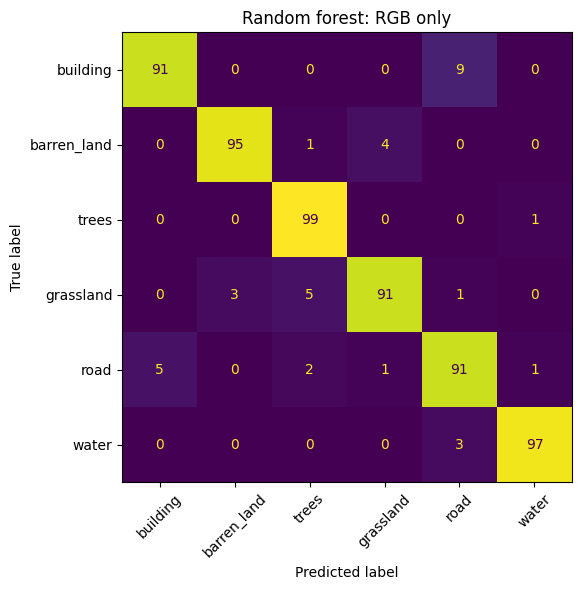

Random forest: R, G, NIR overall accuracy: 0.940
  building: 0.900
  barren_land: 0.960
  trees: 0.960
  grassland: 0.900
  road: 0.920
  water: 1.000


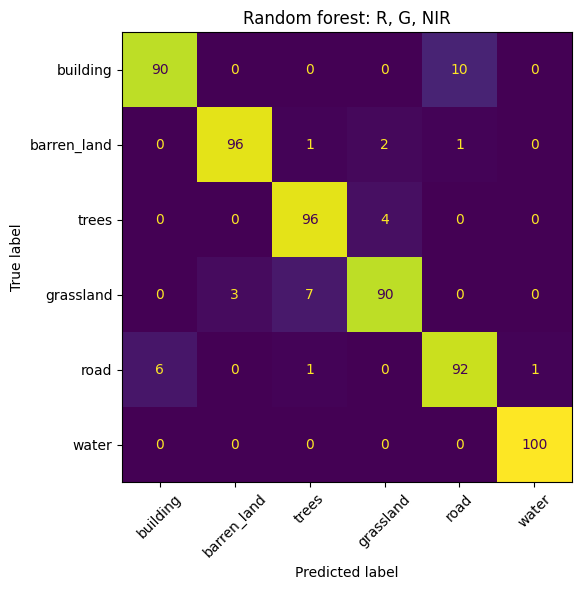

In [16]:
channel_experiments = {
    "RGB only": [0, 1, 2],
    "R, G, NIR": [0, 1, 3],
}

rf_channel_results = {}

for name, channels in channel_experiments.items():
    train_X_channels = select_channels(train_X, channels)
    test_X_channels = select_channels(test_X, channels)

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(train_X_channels, train_y_class)
    pred = model.predict(test_X_channels)

    rf_channel_results[name] = evaluate_predictions(
        test_y_class,
        pred,
        labels,
        f"Random forest: {name}"
    )


## Hyperparameter experiment

I changed max_depth, which limits how deep each decision tree is allowed to grow. My expectation was that max_depth=20 would make the forest a little more robust by avoiding very deep trees that can memorize details of the training set, but it might slightly reduce accuracy because the trees are less flexible.


Random forest with max_depth=20 overall accuracy: 0.948
  building: 0.940
  barren_land: 0.960
  trees: 0.950
  grassland: 0.900
  road: 0.940
  water: 1.000


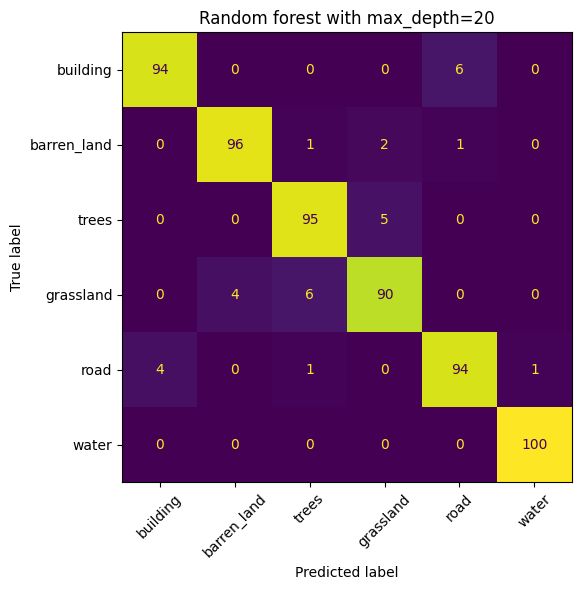

In [17]:
rf_depth20 = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_depth20.fit(train_X, train_y_class)
depth20_pred = rf_depth20.predict(test_X)

rf_depth20_metrics = evaluate_predictions(
    test_y_class,
    depth20_pred,
    labels,
    "Random forest with max_depth=20"
)
